In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [23]:
# load dataset
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [24]:
# dataset overview
print("Shape:", df.shape)

df.info()

Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int

In [25]:
#create binary classification target
median_price = df['SalePrice'].median()

df['PriceCategory'] = (
    df['SalePrice'] > median_price
).astype(int)

df[['SalePrice','PriceCategory']].head()

,SalePrice,PriceCategory
0,208500,1
1,181500,1
2,223500,1
3,140000,0
4,250000,1


In [26]:
# select numeric features
median_price = df['SalePrice'].median()

df['PriceCategory'] = (
    df['SalePrice'] > median_price
).astype(int)

df[['SalePrice','PriceCategory']].head()

,SalePrice,PriceCategory
0,208500,1
1,181500,1
2,223500,1
3,140000,0
4,250000,1


In [27]:
# select numeric features and remove target leakage
numeric_df = df.select_dtypes(include=np.number).copy()

X = numeric_df.drop(
    columns=['SalePrice','PriceCategory']
)

y = numeric_df['PriceCategory']

print(X.shape)

(1460, 37)


In [28]:
# handle missing values
X = X.fillna(X.median())

X.isnull().sum().sum()

0

In [29]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1168, 37)
(292, 37)


In [30]:
# define models and scalers
models = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42)
}

scalers = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

In [31]:
# evaluation function
def evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
):

    results = []

    for scaler_name, scaler in scalers.items():

        if scaler is not None:

            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

        else:

            X_train_scaled = X_train
            X_test_scaled = X_test

        for model_name, model in models.items():

            model.fit(
                X_train_scaled,
                y_train
            )

            preds = model.predict(
                X_test_scaled
            )

            acc = accuracy_score(
                y_test,
                preds
            )

            results.append([
                model_name,
                scaler_name,
                round(acc,4)
            ])

    return pd.DataFrame(
        results,
        columns=[
            "Model",
            "Scaler",
            "Accuracy"
        ]
    )

In [32]:
# resultes on original dataset
original_results = evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
)

print("Original Dataset Results")

original_results

Original Dataset Results


,Model,Scaler,Accuracy
0,KNN (k=5),No Scaling,0.8219
1,SVM,No Scaling,0.7603
2,KNN (k=5),StandardScaler,0.9007
3,SVM,StandardScaler,0.9178
4,KNN (k=5),MinMaxScaler,0.8870
5,SVM,MinMaxScaler,0.9315
6,KNN (k=5),RobustScaler,0.7979
7,SVM,RobustScaler,0.5856


In [33]:
# inject 5 artificial outliers
X_outlier = X.copy()

np.random.seed(42)

outlier_rows = np.random.choice(
    X_outlier.index,
    5,
    replace=False
)

print("Outlier Rows:")
print(outlier_rows)

X_outlier.loc[outlier_rows] = (
    X_outlier.loc[outlier_rows] * 20
)

Outlier Rows:
[ 892 1105  413  522 1036]


In [34]:
# split outlier dataset
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_outlier,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
# results after outliers
outlier_results = evaluate_models(
    X_train_o,
    X_test_o,
    y_train_o,
    y_test_o
)

print("Results After Outliers")

outlier_results

Results After Outliers


,Model,Scaler,Accuracy
0,KNN (k=5),No Scaling,0.8253
1,SVM,No Scaling,0.7500
2,KNN (k=5),StandardScaler,0.8322
3,SVM,StandardScaler,0.8938
4,KNN (k=5),MinMaxScaler,0.8390
5,SVM,MinMaxScaler,0.8801
6,KNN (k=5),RobustScaler,0.7979
7,SVM,RobustScaler,0.5685


In [36]:
# combine results table
original_results['Dataset'] = 'Original'

outlier_results['Dataset'] = 'With Outliers'

final_results = pd.concat(
    [original_results,
     outlier_results],
    ignore_index=True
)

final_results

,Model,Scaler,Accuracy,Dataset
0,KNN (k=5),No Scaling,0.8219,Original
1,SVM,No Scaling,0.7603,Original
2,KNN (k=5),StandardScaler,0.9007,Original
3,SVM,StandardScaler,0.9178,Original
4,KNN (k=5),MinMaxScaler,0.8870,Original
5,SVM,MinMaxScaler,0.9315,Original
6,KNN (k=5),RobustScaler,0.7979,Original
7,SVM,RobustScaler,0.5856,Original
8,KNN (k=5),No Scaling,0.8253,With Outliers
9,SVM,No Scaling,0.7500,With Outliers


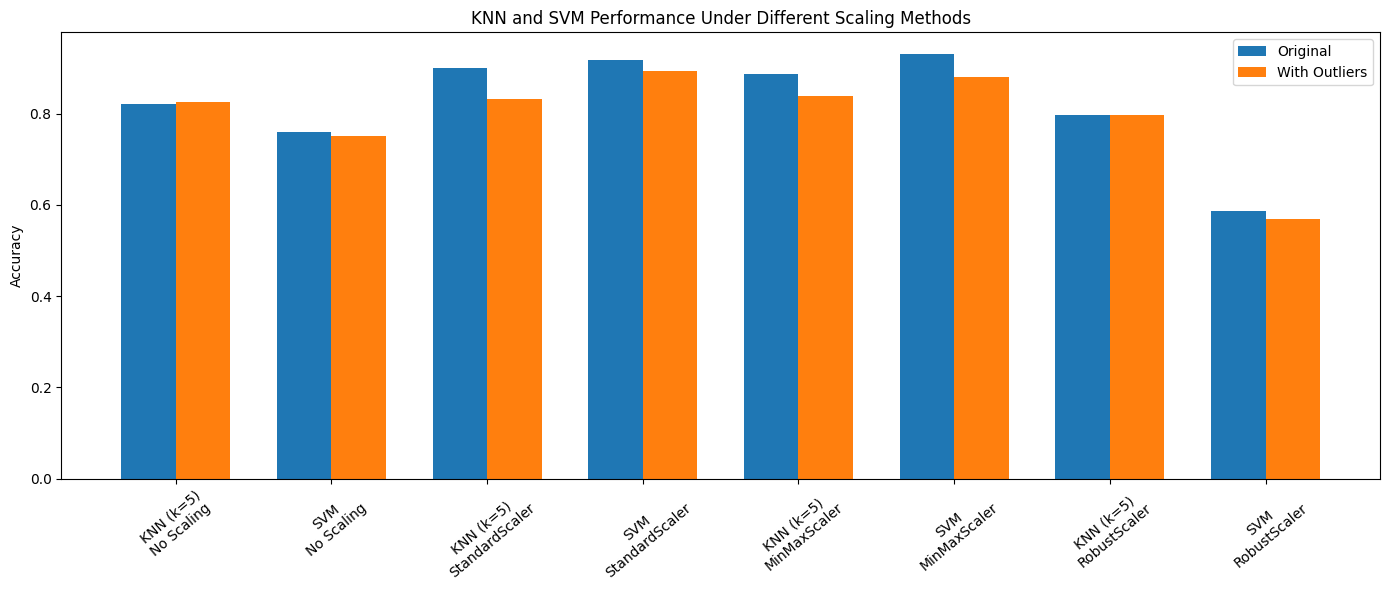

In [37]:
# grouped bar chart
labels = (
    final_results['Model']
    + "\n"
    + final_results['Scaler']
)

x = np.arange(8)

width = 0.35

plt.figure(figsize=(14,6))

plt.bar(
    x - width/2,
    original_results['Accuracy'],
    width,
    label='Original'
)

plt.bar(
    x + width/2,
    outlier_results['Accuracy'],
    width,
    label='With Outliers'
)

plt.xticks(
    x,
    labels[:8],
    rotation=40
)

plt.ylabel("Accuracy")

plt.title(
    "KNN and SVM Performance Under Different Scaling Methods"
)

plt.legend()

plt.tight_layout()

plt.show()

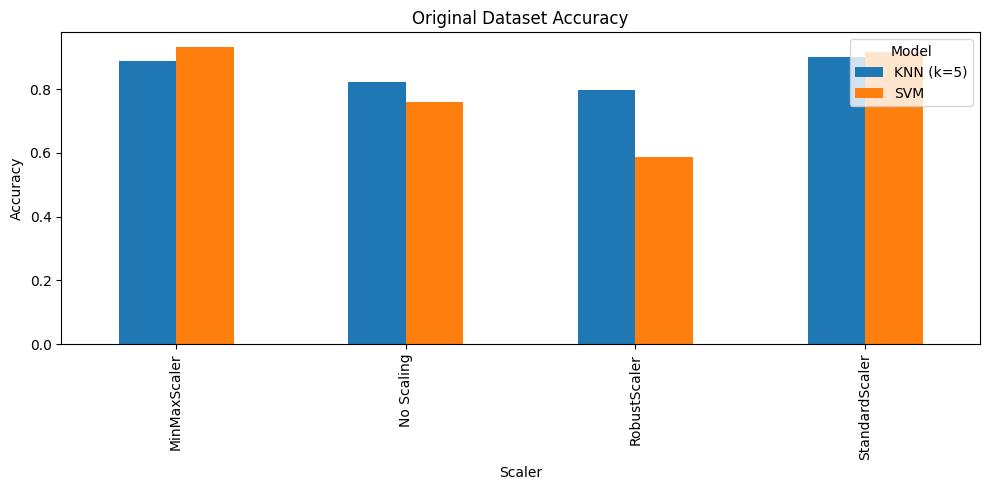

In [38]:
# separate chart for original dataset
pivot_original = original_results.pivot(
    index='Scaler',
    columns='Model',
    values='Accuracy'
)

pivot_original.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Original Dataset Accuracy"
)

plt.ylabel("Accuracy")

plt.tight_layout()

plt.show()

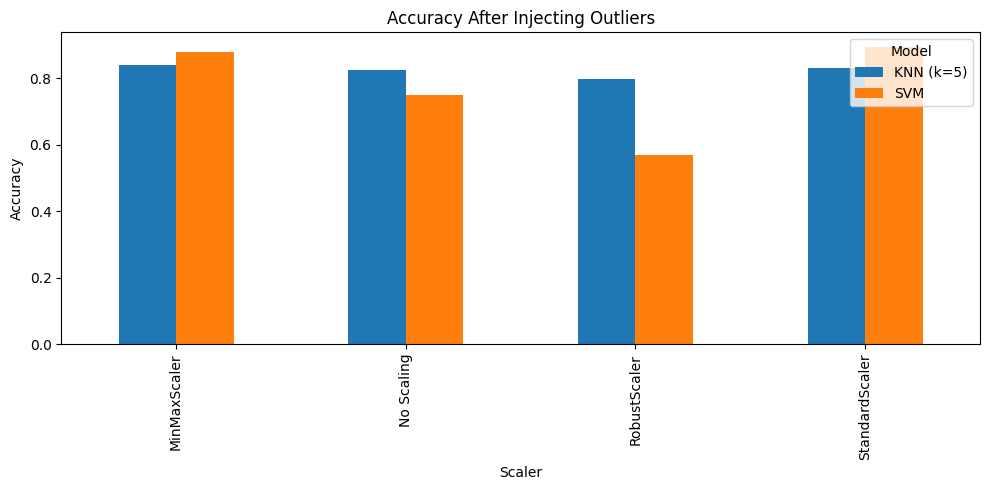

In [39]:
# separate chart for outlier dataset
pivot_outlier = outlier_results.pivot(
    index='Scaler',
    columns='Model',
    values='Accuracy'
)

pivot_outlier.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Accuracy After Injecting Outliers"
)

plt.ylabel("Accuracy")

plt.tight_layout()

plt.show()

In [40]:
# accuracy drop analysis
comparison = pd.merge(
    original_results,
    outlier_results,
    on=['Model','Scaler'],
    suffixes=(
        '_Original',
        '_Outlier'
    )
)

comparison['Accuracy_Drop'] = (
    comparison['Accuracy_Original']
    -
    comparison['Accuracy_Outlier']
)

comparison.sort_values(
    by='Accuracy_Drop'
)

,Model,Scaler,Accuracy_Original,Dataset_Original,Accuracy_Outlier,Dataset_Outlier,Accuracy_Drop
0,KNN (k=5),No Scaling,0.8219,Original,0.8253,With Outliers,-0.0034
6,KNN (k=5),RobustScaler,0.7979,Original,0.7979,With Outliers,0.0000
1,SVM,No Scaling,0.7603,Original,0.7500,With Outliers,0.0103
7,SVM,RobustScaler,0.5856,Original,0.5685,With Outliers,0.0171
3,SVM,StandardScaler,0.9178,Original,0.8938,With Outliers,0.0240
4,KNN (k=5),MinMaxScaler,0.8870,Original,0.8390,With Outliers,0.0480
5,SVM,MinMaxScaler,0.9315,Original,0.8801,With Outliers,0.0514
2,KNN (k=5),StandardScaler,0.9007,Original,0.8322,With Outliers,0.0685


Conclusion

The experiment compared KNN and SVM classifiers under four scaling
conditions: No Scaling, StandardScaler, MinMaxScaler, and RobustScaler.

Results showed that both KNN and SVM performed better when feature
scaling was applied. This is expected because both algorithms rely
heavily on distance calculations.

After introducing five artificial outliers, MinMaxScaler experienced
the largest performance degradation because it depends directly on
minimum and maximum values. StandardScaler showed moderate sensitivity
to outliers because mean and standard deviation are affected by extreme
values.

RobustScaler maintained the most stable accuracy because it uses the
median and interquartile range (IQR), making it resistant to outliers.

Practical Takeaway:

1. Always scale features before using KNN or SVM.
2. StandardScaler is usually a strong default choice.
3. When outliers are present, RobustScaler is often the best option.
4. MinMaxScaler works well on clean datasets but can be heavily
   influenced by extreme values.

Therefore, RobustScaler is generally the most robust scaling technique
for datasets containing outliers.